In [59]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
file_path = "Mall_Customers.csv"

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "vjchoudhary7/customer-segmentation-tutorial-in-python",
  file_path,)

print("First 5 records:", df.head())

/tmp/ipykernel_20165/1808456946.py:6: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'customer-segmentation-tutorial-in-python' dataset.
First 5 records:    CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [80]:
import plotly.express as px
x = df['Annual Income (k$)']
y = df['Spending Score (1-100)']
z = df['Age']

fig = px.scatter_3d(df, x='Annual Income (k$)', y='Spending Score (1-100)', z='Age', color='Age',
                    title='Interactive 3D Scatter Plot of Annual Income, Spending Score, and Age',
                    labels={'Annual Income (k$)': 'Annual Income (k$)', 'Spending Score (1-100)': 'Spending Score (1-100)', 'Age': 'Age'})

fig.update_layout(scene = dict(
                    xaxis_title='Annual Income (k$)',
                    yaxis_title='Spending Score (1-100)',
                    zaxis_title='Age'))
plt.fig()
fig.show()

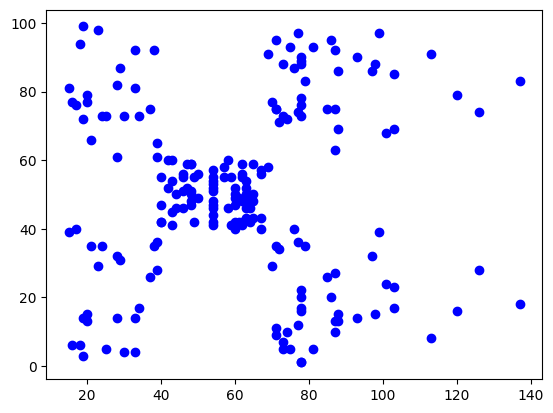

In [76]:
plt.scatter(df['Annual Income (k$)'],df['Spending Score (1-100)'],color='b')

In [61]:
Dataset=df.iloc[:,-2:]
Dataset

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


**Finding the optimal number of clusters using the dendrogram**

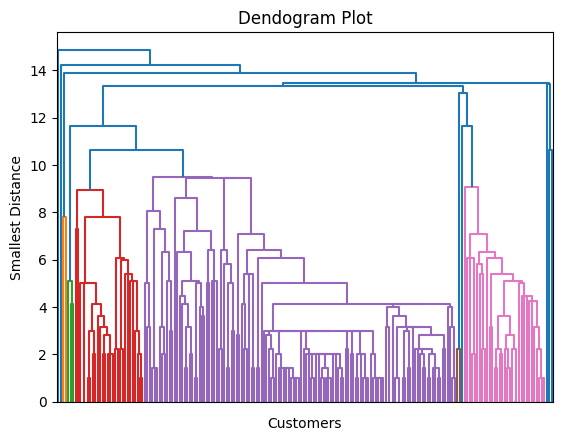

In [62]:
import scipy.cluster.hierarchy as sch
dendo=sch.dendrogram(sch.linkage(Dataset,method="single"))
plt.title("Dendogram Plot")
plt.ylabel("Smallest Distance")
plt.xlabel("Customers")
plt.xticks(list(range(0,2500,500)))
plt.show()

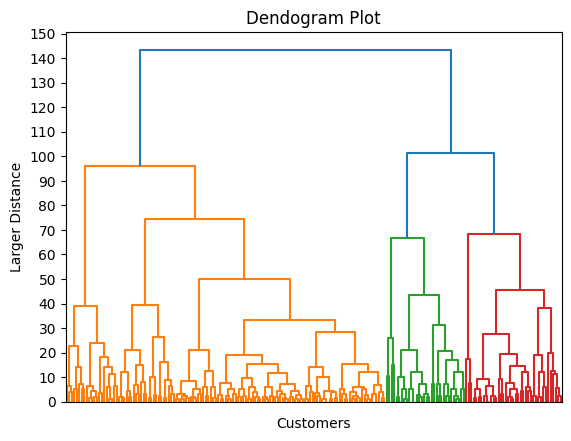

In [63]:
import scipy.cluster.hierarchy as sch
dendo=sch.dendrogram(sch.linkage(Dataset,method="complete"))
plt.title("Dendogram Plot")
plt.ylabel("Larger Distance")
plt.xlabel("Customers")
plt.yticks(list(range(0,160,10)))
plt.xticks(list(range(0,2500,500)))
plt.show()

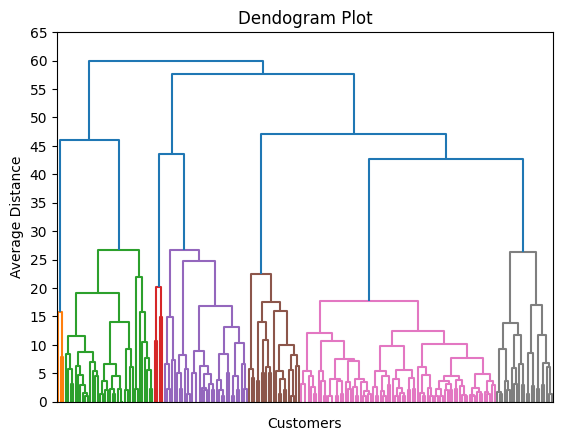

In [64]:
import scipy.cluster.hierarchy as sch
dendo=sch.dendrogram(sch.linkage(Dataset,method="average"))
plt.title("Dendogram Plot")
plt.ylabel("Average Distance")
plt.xlabel("Customers")
plt.yticks(list(range(0,70,5)))
plt.xticks(list(range(0,4000,2000)))
plt.show()

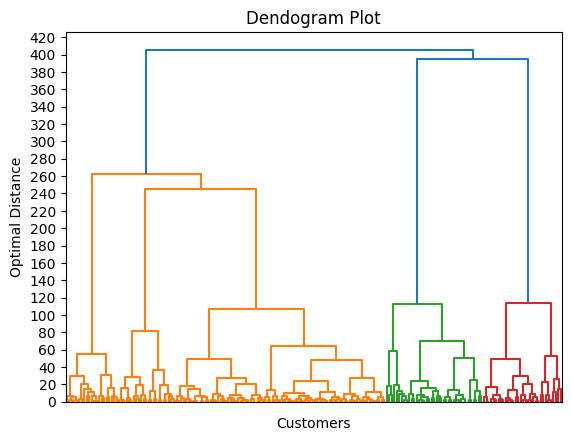

In [65]:
import scipy.cluster.hierarchy as sch
dendo=sch.dendrogram(sch.linkage(Dataset,method="ward"))
plt.title("Dendogram Plot")
plt.ylabel("Optimal Distance")
plt.xlabel("Customers")
plt.yticks(list(range(0,440,20)))
plt.xticks(list(range(0,4000,2000)))
plt.show()

In [66]:
from sklearn.cluster import AgglomerativeClustering
Her_cluster=AgglomerativeClustering(n_clusters=5,metric='euclidean',linkage='ward')
y_pred=Her_cluster.fit_predict(Dataset)
y_pred

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 1,
       4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 2, 0, 2, 0, 2,
       1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2])

In [67]:
Dataset["Cluster"]=y_pred
Dataset

,Annual Income (k$),Spending Score (1-100),Cluster
0,15,39,4
1,15,81,3
2,16,6,4
3,16,77,3
4,17,40,4
...,...,...,...
195,120,79,2
196,126,28,0
197,126,74,2
198,137,18,0


In [68]:
df0=Dataset[Dataset.Cluster==0]
df0

,Annual Income (k$),Spending Score (1-100),Cluster
128,71,11,0
130,71,9,0
134,73,5,0
136,73,7,0
138,74,10,0
140,75,5,0
144,77,12,0
148,78,22,0
150,78,17,0
152,78,20,0


In [69]:
df1=Dataset[Dataset.Cluster==1]
df1

,Annual Income (k$),Spending Score (1-100),Cluster
43,39,61,1
45,39,65,1
46,40,55,1
47,40,47,1
48,40,42,1
...,...,...,...
126,71,35,1
132,72,34,1
142,76,40,1
146,77,36,1


In [70]:
df2=Dataset[Dataset.Cluster==2]
df2

,Annual Income (k$),Spending Score (1-100),Cluster
123,69,91,2
125,70,77,2
127,71,95,2
129,71,75,2
131,71,75,2
133,72,71,2
135,73,88,2
137,73,73,2
139,74,72,2
141,75,93,2


In [71]:
df3=Dataset[Dataset.Cluster==3]
df3

,Annual Income (k$),Spending Score (1-100),Cluster
1,15,81,3
3,16,77,3
5,17,76,3
7,18,94,3
9,19,72,3
11,19,99,3
13,20,77,3
15,20,79,3
17,21,66,3
19,23,98,3


In [72]:
df4=Dataset[Dataset.Cluster==4]
df4

,Annual Income (k$),Spending Score (1-100),Cluster
0,15,39,4
2,16,6,4
4,17,40,4
6,18,6,4
8,19,3,4
10,19,14,4
12,20,15,4
14,20,13,4
16,21,35,4
18,23,29,4


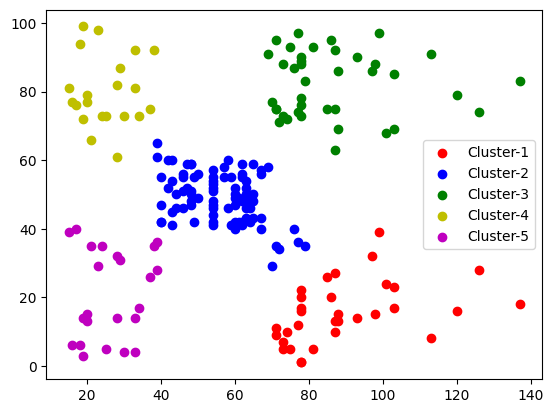

In [75]:
plt.scatter(df0['Annual Income (k$)'],df0['Spending Score (1-100)'],color='r',label='Cluster-1')
plt.scatter(df1['Annual Income (k$)'],df1['Spending Score (1-100)'],color='b',label='Cluster-2')
plt.scatter(df2['Annual Income (k$)'],df2['Spending Score (1-100)'],color='g',label='Cluster-3')
plt.scatter(df3['Annual Income (k$)'],df3['Spending Score (1-100)'],color='y',label='Cluster-4')
plt.scatter(df4['Annual Income (k$)'],df4['Spending Score (1-100)'],color='m',label='Cluster-5')
plt.legend()
plt.show()